# Machine Learining Assignent 6


Name - Lalit Pathade

PRN - 12411458

Roll No. - 58

Assignment 6

• Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the following:

• a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis

• b. Bivariate analysis: Linear and logistic regression modeling

• c. Multiple Regression analysis

*1. Importing Required Libraries*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix


*2. Extracting Dataset*

In [ ]:
df = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
diabetes = load_diabetes()
sklearn_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
sklearn_df['target'] = diabetes.target

print("Sklearn Diabetes Shape:", sklearn_df.shape)

p = diabetes.feature_names
print(p)
sklearn_df


Sklearn Diabetes Shape: (442, 11)
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


*3. Basic statistics*

In [ ]:
def univariate_summary(df):
    df_numeric = df.select_dtypes(include=['number'])

    summary = pd.DataFrame({
        "Mean": df_numeric.mean(),
        "Median": df_numeric.median(),
        "Mode": df_numeric.mode().iloc[0],
        "Skewness": df_numeric.skew(),
        "Kurtosis": df_numeric.kurtosis(),
        "Variance": df_numeric.var(),
        "Std Dev": df_numeric.std()
    })

    return summary.T

In [ ]:
print("Univariate Analysis - df Dataset")
print(univariate_summary(df))

print("Sklearn Diabetes Dataset")
print(univariate(sklearn_df))

Univariate Analysis - df Dataset
          Pregnancies      Glucose  BloodPressure  SkinThickness  \
Mean         3.845052   120.894531      69.105469      20.536458   
Median       3.000000   117.000000      72.000000      23.000000   
Mode         1.000000    99.000000      70.000000       0.000000   
Skewness     0.901674     0.173754      -1.843608       0.109372   
Kurtosis     0.159220     0.640780       5.180157      -0.520072   
Variance    11.354056  1022.248314     374.647271     254.473245   
Std Dev      3.369578    31.972618      19.355807      15.952218   

               Insulin        BMI  DiabetesPedigreeFunction         Age  \
Mean         79.799479  31.992578                  0.471876   33.240885   
Median       30.500000  32.000000                  0.372500   29.000000   
Mode          0.000000  32.000000                  0.254000   22.000000   
Skewness      2.272251  -0.428982                  1.919911    1.129597   
Kurtosis      7.214260   3.290443              

*4. Frequency for target variable*

In [ ]:
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
print(df[df["Age"] > 30]["Outcome"].value_counts())

Outcome
1    178
0    173
Name: count, dtype: int64


In [ ]:
print(df[df["Age"] < 30]["Outcome"].value_counts())

Outcome
0    312
1     84
Name: count, dtype: int64


In [ ]:
print(sklearn_df["target"].value_counts())

target
200.0    6
72.0     6
178.0    5
71.0     5
90.0     5
        ..
146.0    1
212.0    1
120.0    1
183.0    1
57.0     1
Name: count, Length: 214, dtype: int64


*Removing Outliers*

In [ ]:
print("Original Shape:", sklearn_df.shape)

Original Shape: (442, 12)


In [ ]:
clean_df = sklearn_df.copy()

for col in clean_df.columns:
    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    clean_df = clean_df[(clean_df[col] >= lower) & (clean_df[col] <= upper)]

print("\nAfter Removing Outliers Shape:", clean_df.shape)


After Removing Outliers Shape: (407, 12)


# Bivariate Analysis

*Linear Rgression*

In [ ]:
print("LINEAR REGRESSION (BMI vs Target)")

X = clean_df[['bmi']]
y = clean_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)

print("Coefficient:", lin_model.coef_[0])
print("Intercept:", lin_model.intercept_)
print("R2 Score:", r2_score(y_test, y_pred))

LINEAR REGRESSION (BMI vs Target)
Coefficient: 913.9341780165009
Intercept: 150.618900550211
R2 Score: 0.43779798609188814


*Graph*

Scatter Plot

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


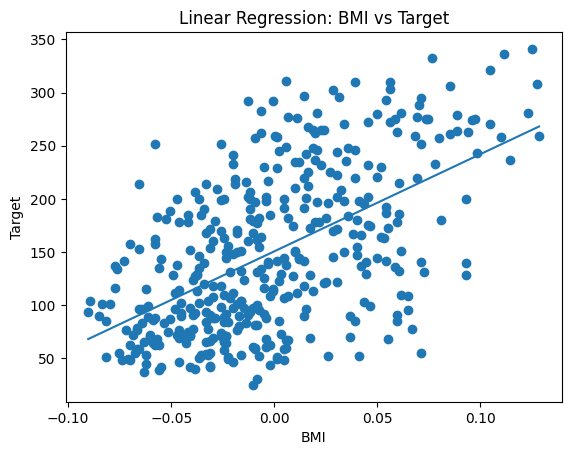

In [ ]:
y_pred = lin_model.predict(X)

# Create smooth regression line
x_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
y_line = lin_model.predict(x_line)

# Plot
plt.figure()
plt.scatter(X, y)
plt.plot(x_line, y_line)

plt.title("Linear Regression: BMI vs Target")
plt.xlabel("BMI")
plt.ylabel("Target")
plt.show()


**Histogram**

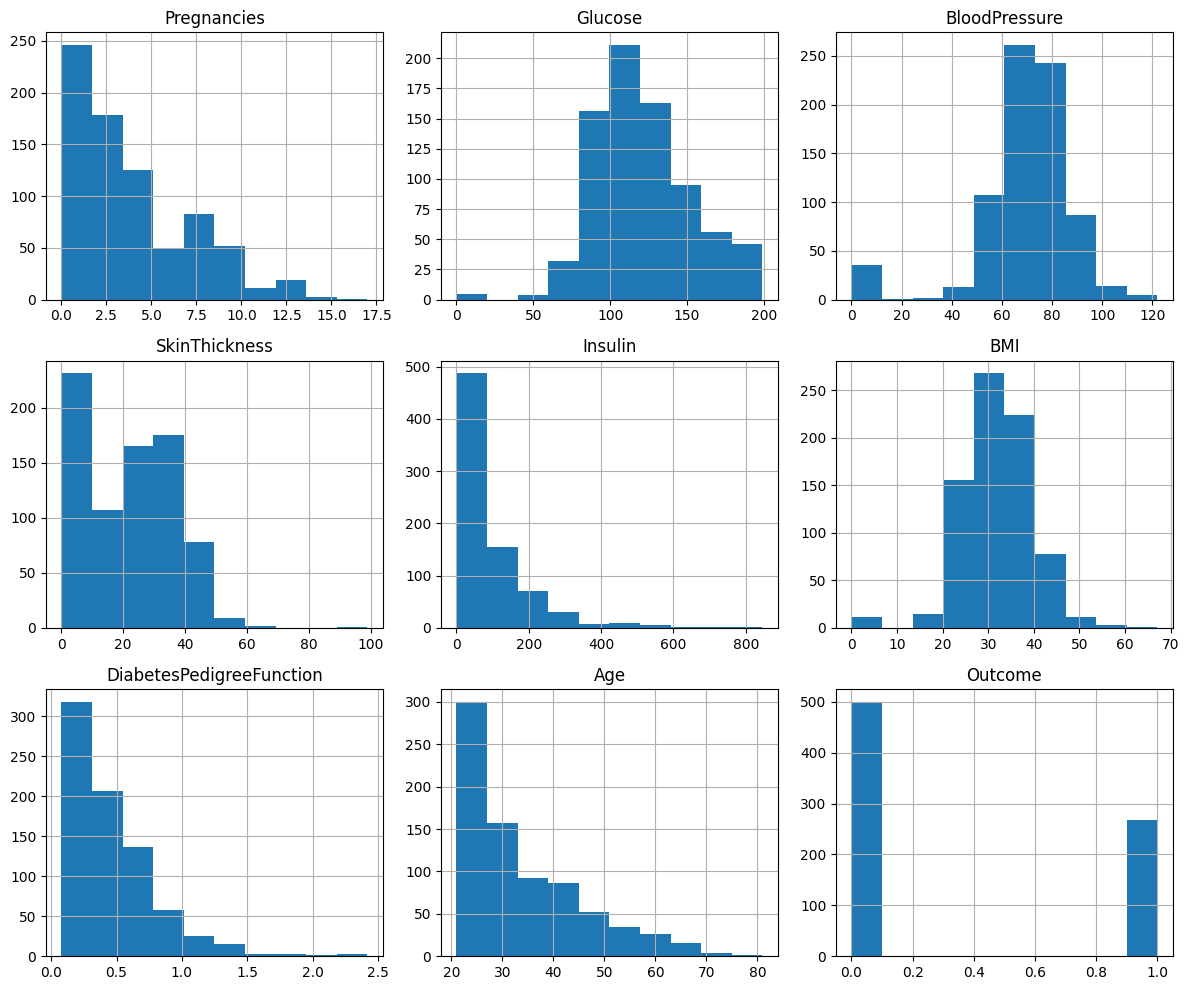

In [ ]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()


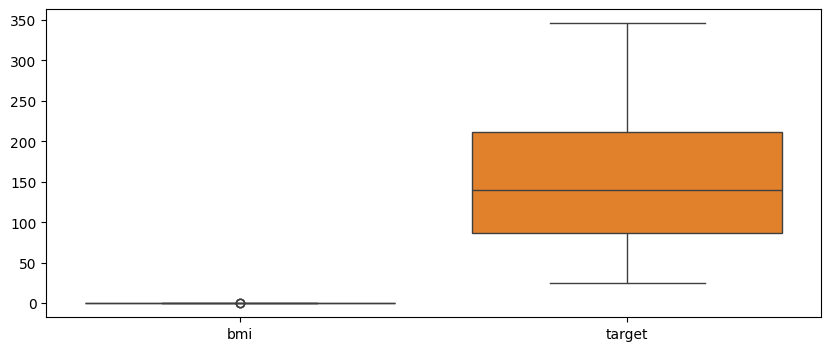

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.boxplot(data=sklearn_df[['bmi','target']])
plt.show()


correlation

In [ ]:
corr = df.corr()
corr1 = sklearn_df.corr()
print(corr)
print(corr1)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

# Logistic Regession


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

sklearn_df['binary_target'] = (sklearn_df['target'] > sklearn_df['target'].median()).astype(int)

X = sklearn_df[['bmi']]
y = sklearn_df['binary_target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print(" LOGISTIC REGRESSION ")
print("Accuracy:", accuracy_score(y_test, y_pred))

 LOGISTIC REGRESSION 
Accuracy: 0.7078651685393258


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


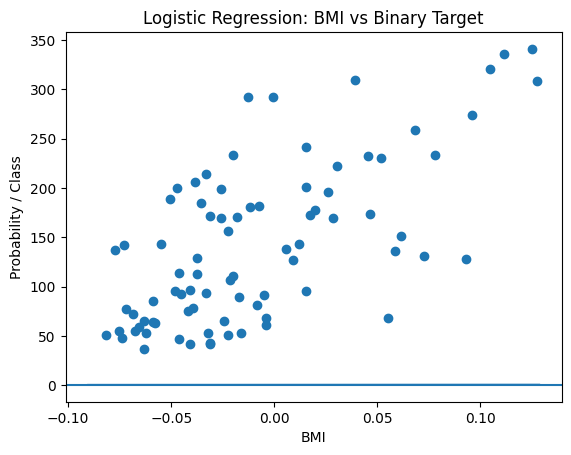

In [ ]:
X_vis = X_test['bmi'].values
y_vis = y_test.values

# Create smooth BMI range for sigmoid curve
bmi_range = np.linspace(X['bmi'].min(), X['bmi'].max(), 300).reshape(-1, 1)

# Get probability predictions from trained model
probabilities = log_model.predict_proba(bmi_range)[:, 1]

# Plot
plt.figure()

# Scatter actual test data
plt.scatter(X_vis, y_vis)

# Plot sigmoid curve
plt.plot(bmi_range, probabilities)

# Decision boundary at 0.5
plt.axhline(0.5)

plt.xlabel("BMI")
plt.ylabel("Probability / Class")
plt.title("Logistic Regression: BMI vs Binary Target")

plt.show()